## A summary of model development to correct representational drift

The list of the models:
- single-layer Hebbian network
    - Oja multi-neuron network
    - Sanger multi-neuron network
    - Leen's minimal network

- two-layer Hebbain/anti-Hebbian network with lateral connections
    - Foldiak network
    - Leen's complete activity-dependent network
    - Leen & Freisleben network

The models will be tested to decode the task variable. The task variable will be constructed by the linear combination of the eigenvectors of the input data matrix. 

In [1]:
# import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hebbian.models import OjaNetwork, SangerNetwork, FoldiakPCA, OneShotLeenCompletePCA, OneShotLeenFreislebenPCA
from hebbian.utils import Y_aligned_training_testing_online, generate_covariance_matrix, instantiate_samples_by_cov, rotation_matrix_nd, pca_topk, best_match_align_eigenvectors, sign_check
from sklearn.metrics import r2_score

### Data sample generation

In [2]:
N = 64
m = 8
phi_deg = 75.0
n_samples = 10001
X_seed = 0
# get /sigma

eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

R = rotation_matrix_nd(m, axis1=0, axis2=1, phi_rad=np.deg2rad(phi_deg))
Sigma_rot = R @ Sigma @ R.T

X_before = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)
X_after = instantiate_samples_by_cov(Sigma_rot, N, m, seed=X_seed, n_samples=n_samples)

pcs_before, _, scores_before = pca_topk(X_before, k=m)
pcs_after, _, scores_after = pca_topk(X_after, k=m)


### Helper functions of decoding task variable by different models

In [3]:
from tqdm import tqdm
### calculate the task variable across time

# generate values between 0 and 1 for m number
rng_para = np.random.default_rng(seed=42)
params = rng_para.random(m)
batch_size = 1
runs = 100

def decoding_task_variable_optimized(model, data, params, pcs=None, scores=None, batch_size=1, output_size=None, runs=runs, graph=True):
    # If output_size wasn't defined in context, assume it matches params or data
    if output_size is None:
        output_size = params.shape[0] # or defined m

    # 1. Pre-calculate PCA once (assuming data doesn't change between runs)
    # This utilizes M1 vectorization efficiently
    if pcs is None or scores is None:
        pcs, _, scores = pca_topk(data, k=output_size)
    
    # 2. Calculate target task variable
    task_var = np.dot(scores, params)
    
    # Initialize storage
    df_task_var_tilde = pd.DataFrame(np.zeros((runs, data.shape[0])))
    n_samples = data.shape[0]

    # Outer loop: Sequential (as requested)
    # Using tqdm for a clean progress bar
    for run in tqdm(range(runs), desc="Runs"):
        
        # --- OPTIMIZATION START ---
        # We run the training loop strictly for training.
        # No heavy evaluation happens here.
        for step in range(0, n_samples, batch_size):
            X_train = data[step:step+batch_size]
            model.step(X_train) 
            # Note: If you need to incrementally reveal the input matrix 
            # for 'model.transform', logic needs to change, but standard 
            # Hebbian/Oja usually just updates weights here.
            
        # --- EVALUATION ---
        # We only transform and align ONCE per run, after the model 
        # has seen the full dataset for this epoch.
        Y_output = model.transform(data)
        
        try:
            V = model.V
        except AttributeError:
            V = None

        # This expensive step now happens 1 time per run, instead of N times
        order, _, _ = best_match_align_eigenvectors(model.W, V, pcs)
        
        signs = sign_check(Y_output, scores, order)
        Y_output_signed = Y_output * signs[None, :]
        task_var_tilde = np.dot(Y_output_signed, params)
        
        # Save result
        df_task_var_tilde.iloc[run, :] = task_var_tilde
        # --- OPTIMIZATION END ---

        if graph:
            # Calculate correlation for the title
            r_squared = np.corrcoef(task_var, task_var_tilde)[0, 1]**2
            
            plt.figure(figsize=(20, 5))
            plt.plot(task_var[:200], label="Target Task Variable")
            plt.plot(task_var_tilde[:200], label="Decoded Task Variable")
            plt.title(f"Run {run+1}, {model.__class__.__name__}, $R^2$ = {r_squared:.2f}")
            plt.legend()
            plt.show()
        
        # Reset model for the next run
        model.reset()

    return task_var, df_task_var_tilde


def get_task_variable_random(random_model, data, params, pcs=None, scores=None):
    df_task_var_random = pd.DataFrame(np.zeros((runs, data.shape[0])))
    for run in tqdm(range(runs), desc="Runs"):
        # define random network
        random_model.reset()
        Y_output_random = random_model.transform(data)
        if pcs is None or scores is None:
            pcs, _, scores = pca_topk(data, k=m)
        W = random_model.W
        try:
            V = random_model.V
        except AttributeError:
            V= None
        order, sim, _ = best_match_align_eigenvectors(W, V=V, eigenvectors=pcs)

        signs = sign_check(Y_output_random, scores, order)
        # Apply sign corrections
        Y_output_signed_random = Y_output_random * signs[None, :]
        # Now compute task variable with sign-corrected output
        task_var_random = np.dot(Y_output_signed_random, params)
        df_task_var_random.iloc[run, :] = task_var_random
    return df_task_var_random


def plot_task_variable_decoding(task_var, mean_df_task_var_random, mean_df_task_var_tilde, std_df_task_var_random, std_df_task_var_tilde, model, display_length=100):
    plt.figure(figsize=(20, 5))
    plt.plot(task_var[:display_length], label="Target Task Variable")

    # get the mean and variance of the rows
    # (Assuming you calculated mean_df_task_var_random somewhere above based on your snippet)

    r_squared_random = r2_score(task_var, mean_df_task_var_random)
    r_squared_tilde = r2_score(task_var, mean_df_task_var_tilde)

    plt.plot(mean_df_task_var_tilde[:display_length], label="Decoded Task Variable")
    plt.fill_between(range(display_length), 
                    mean_df_task_var_tilde[:display_length] - std_df_task_var_tilde[:display_length], 
                    mean_df_task_var_tilde[:display_length] + std_df_task_var_tilde[:display_length], 
                    alpha=0.2)

    plt.plot(mean_df_task_var_random[:display_length], label="Random Decoded Task Variable")
    plt.fill_between(range(display_length), 
                    mean_df_task_var_random[:display_length] - std_df_task_var_random[:display_length], 
                    mean_df_task_var_random[:display_length] + std_df_task_var_random[:display_length], 
                    alpha=0.2)
    # --- NEW: Update Title ---
    plt.title(f"Decoded Task Variable, {model.__class__.__name__}, $R^2$ = random: {r_squared_random:.2f}, after learning: {r_squared_tilde:.2f}")
    plt.legend()
    plt.show()



### Models testing

In [4]:
leen_paras = dict(
    input_size=N, output_size=m,
    eta_w=5e-4,          # base
    eta_v=1e-3,          # ~4x eta_w
    C=3,
    # ema_alpha=0.05,
    symmetrize_V=True,
    seed=None,
    # noise_level=0.001,
    # settling_steps=10
)

hebb_paras = dict(input_size=N, output_size=m, learning_rate=0.011)
foldiak_paras = dict(input_size=N, output_size=m, eta_w=1e-3, eta_v=1e-2)

models = {
    "OjaNetwork": OjaNetwork(**hebb_paras),
    "SangerNetwork": SangerNetwork(**hebb_paras),
    "FoldiakPCA": FoldiakPCA(**foldiak_paras),
    "OneShotLeenCompletePCA": OneShotLeenCompletePCA(**leen_paras),
    "OneShotLeenFreislebenPCA": OneShotLeenFreislebenPCA(**leen_paras),
}

### Alignment between Y outputs and PCs

run  1
X_before
step    0 | order = [6 3 1 7 0 5 2 4] | best|corr|= [0.173 0.33  0.165 0.151 0.099 0.265 0.23  0.074]
step 1000 | order = [4 3 1 0 2 5 7 6] | best|corr|= [0.181 0.339 0.504 0.904 0.188 0.284 0.003 0.169]
step 2000 | order = [2 3 1 0 4 5 7 6] | best|corr|= [0.461 0.512 0.818 0.953 0.269 0.321 0.019 0.149]
step 3000 | order = [2 3 1 0 4 5 7 6] | best|corr|= [0.488 0.74  0.842 0.988 0.463 0.373 0.023 0.133]
step 4000 | order = [2 3 1 0 4 5 7 6] | best|corr|= [0.505 0.814 0.844 0.98  0.592 0.424 0.027 0.133]
step 5000 | order = [2 3 1 0 4 5 7 6] | best|corr|= [0.541 0.828 0.884 0.978 0.632 0.483 0.029 0.137]
step 6000 | order = [2 3 1 0 4 5 7 6] | best|corr|= [0.521 0.842 0.889 0.984 0.629 0.538 0.03  0.141]
step 7000 | order = [2 3 1 0 4 5 7 6] | best|corr|= [0.588 0.85  0.877 0.995 0.619 0.584 0.028 0.141]
step 8000 | order = [2 3 1 0 4 5 7 6] | best|corr|= [0.574 0.868 0.868 0.961 0.6   0.629 0.028 0.138]
step 9000 | order = [2 3 1 0 7 5 4 6] | best|corr|= [0.635 0.886 0

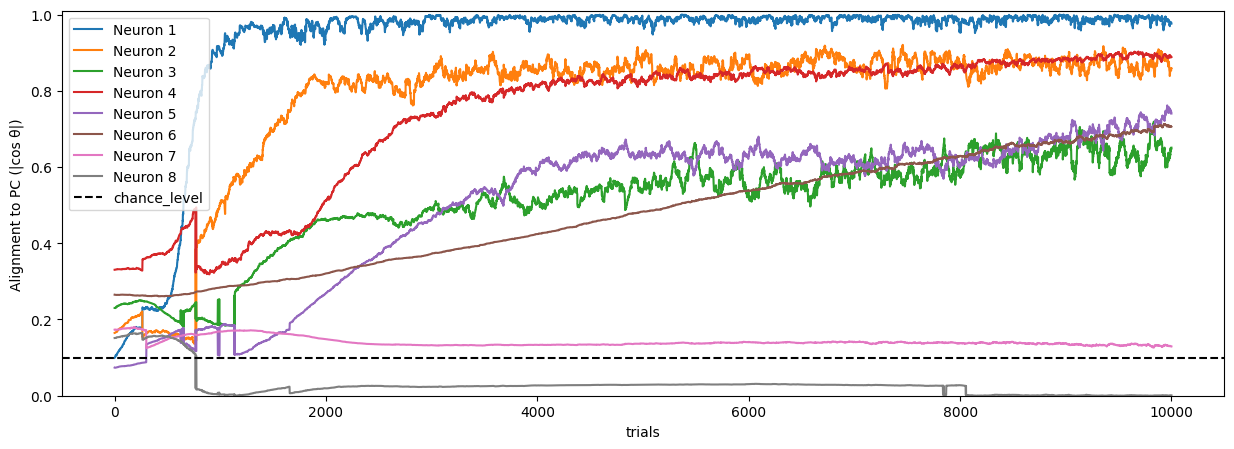

X_after
step    0 | order = [2 3 1 0 6 5 4 7] | best|corr|= [0.6   0.79  0.544 0.835 0.262 0.696 0.667 0.132]
step 1000 | order = [2 3 1 0 6 5 4 7] | best|corr|= [0.668 0.85  0.663 0.93  0.215 0.723 0.738 0.183]
step 2000 | order = [2 3 1 0 6 5 4 7] | best|corr|= [0.713 0.883 0.661 0.954 0.168 0.753 0.738 0.165]
step 3000 | order = [2 3 1 0 6 5 4 7] | best|corr|= [0.72  0.873 0.705 0.91  0.126 0.776 0.732 0.151]
step 4000 | order = [2 3 1 0 6 5 4 7] | best|corr|= [0.623 0.868 0.577 0.958 0.117 0.776 0.832 0.132]
step 5000 | order = [2 3 1 0 6 5 4 7] | best|corr|= [0.672 0.862 0.531 0.9   0.084 0.79  0.816 0.111]
step 6000 | order = [2 3 1 0 6 5 4 7] | best|corr|= [0.558 0.837 0.52  0.936 0.067 0.801 0.863 0.095]
step 7000 | order = [2 3 1 0 6 5 4 7] | best|corr|= [0.657 0.828 0.479 0.959 0.045 0.802 0.817 0.084]
step 8000 | order = [2 1 3 0 6 5 4 7] | best|corr|= [0.646 0.379 0.809 0.991 0.035 0.79  0.824 0.069]
step 9000 | order = [2 1 3 0 6 5 4 7] | best|corr|= [0.672 0.533 0.757 0.8

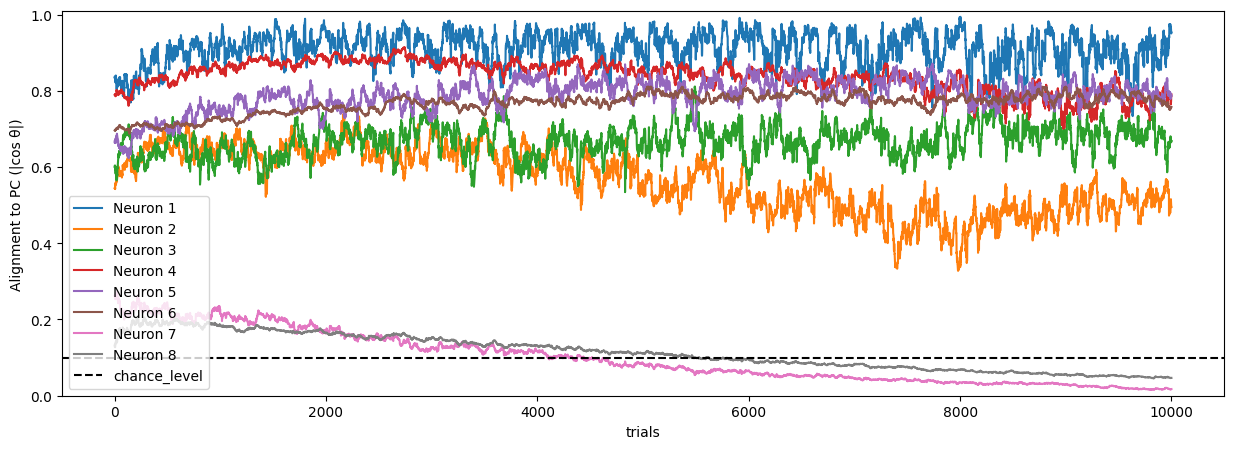

run  2
X_before
step    0 | order = [7 1 3 2 4 0 5 6] | best|corr|= [0.148 0.096 0.252 0.231 0.12  0.185 0.225 0.248]
step 1000 | order = [2 5 3 4 6 0 7 1] | best|corr|= [0.217 0.249 0.324 0.206 0.041 0.787 0.169 0.601]
step 2000 | order = [2 5 3 4 6 0 7 1] | best|corr|= [0.159 0.249 0.527 0.237 0.003 0.944 0.155 0.961]
step 3000 | order = [2 5 3 4 6 0 7 1] | best|corr|= [0.34  0.313 0.755 0.242 0.011 0.993 0.16  0.965]
step 4000 | order = [2 5 3 4 6 0 7 1] | best|corr|= [0.559 0.377 0.841 0.282 0.019 0.989 0.17  0.96 ]
step 5000 | order = [2 4 3 7 6 0 5 1] | best|corr|= [0.762 0.412 0.859 0.107 0.026 0.98  0.382 0.943]
step 6000 | order = [2 4 3 7 6 0 5 1] | best|corr|= [0.883 0.402 0.907 0.145 0.031 0.988 0.349 0.949]
step 7000 | order = [2 4 3 7 6 0 5 1] | best|corr|= [0.926 0.529 0.921 0.155 0.033 0.996 0.347 0.951]
step 8000 | order = [2 4 3 7 6 0 5 1] | best|corr|= [0.919 0.702 0.934 0.153 0.033 0.987 0.404 0.943]
step 9000 | order = [2 4 3 7 6 0 5 1] | best|corr|= [0.949 0.82  0

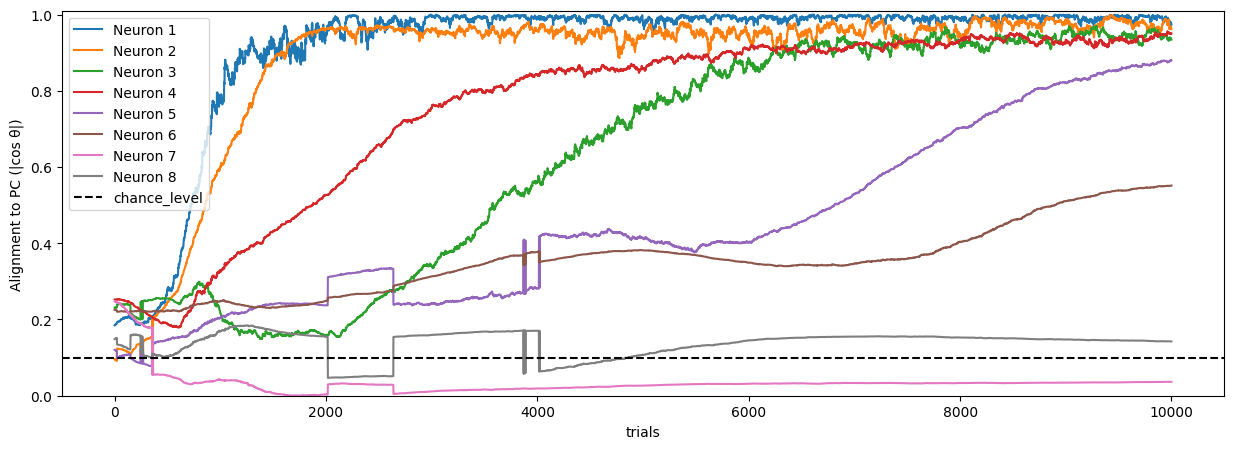

X_after
step    0 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.903 0.791 0.836 0.062 0.032 0.835 0.532 0.732]
step 1000 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.947 0.854 0.898 0.137 0.027 0.958 0.582 0.943]
step 2000 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.954 0.895 0.929 0.149 0.025 0.992 0.6   0.977]
step 3000 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.99  0.906 0.944 0.161 0.024 0.996 0.622 0.993]
step 4000 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.968 0.93  0.937 0.17  0.024 0.991 0.651 0.993]
step 5000 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.983 0.931 0.959 0.179 0.025 0.982 0.692 0.996]
step 6000 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.971 0.928 0.968 0.189 0.026 0.989 0.739 0.993]
step 7000 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.989 0.949 0.969 0.202 0.028 0.996 0.784 0.992]
step 8000 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.979 0.956 0.96  0.214 0.03  0.982 0.833 0.99 ]
step 9000 | order = [2 4 3 6 7 0 5 1] | best|corr|= [0.988 0.957 0.969 0.2

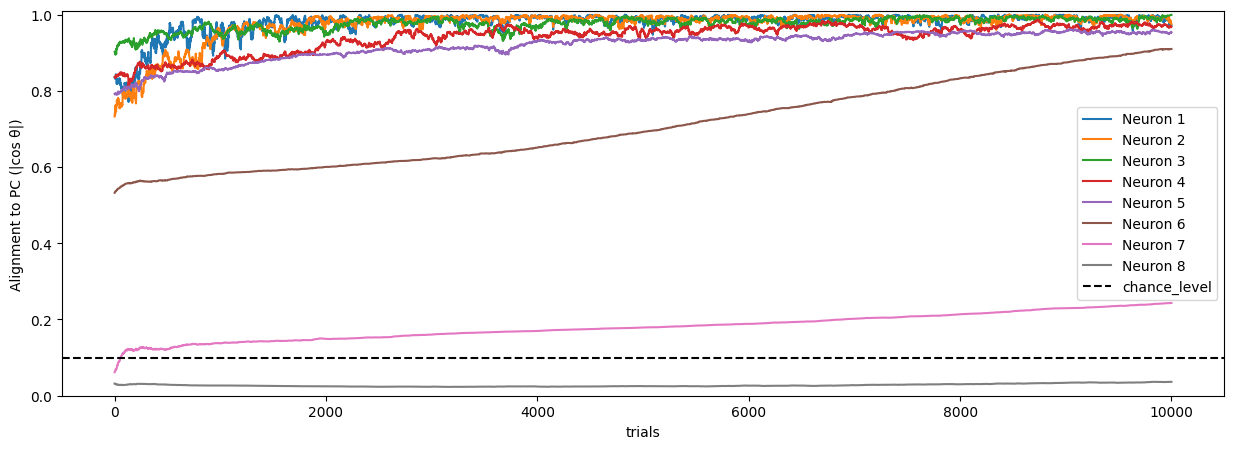

run  3
X_before
step    0 | order = [0 5 4 1 7 2 6 3] | best|corr|= [0.147 0.203 0.158 0.126 0.269 0.25  0.158 0.205]
step 1000 | order = [6 5 7 4 1 2 0 3] | best|corr|= [0.117 0.226 0.024 0.227 0.696 0.295 0.941 0.202]
step 2000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.129 0.235 0.174 0.312 0.973 0.705 0.949 0.01 ]
step 3000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.137 0.267 0.195 0.275 0.99  0.971 0.999 0.002]
step 4000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.149 0.323 0.236 0.266 0.992 0.998 0.993 0.002]
step 5000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.166 0.395 0.298 0.287 0.995 0.997 0.981 0.007]
step 6000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.182 0.472 0.429 0.343 0.993 0.995 0.997 0.011]
step 7000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.193 0.535 0.567 0.458 0.993 0.996 0.996 0.012]
step 8000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.199 0.591 0.669 0.592 0.992 0.98  0.982 0.011]
step 9000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.199 0.629 0

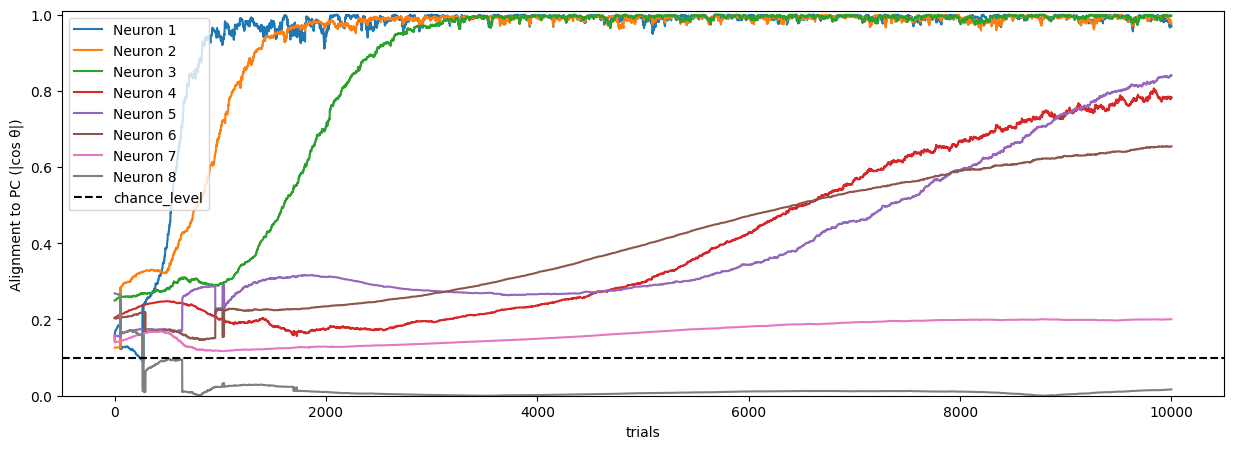

X_after
step    0 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.175 0.616 0.688 0.785 0.707 0.958 0.826 0.032]
step 1000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.207 0.656 0.784 0.889 0.904 0.983 0.955 0.035]
step 2000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.195 0.691 0.84  0.921 0.969 0.978 0.99  0.052]
step 3000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.191 0.737 0.867 0.937 0.992 0.982 0.996 0.056]
step 4000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.187 0.791 0.843 0.959 0.99  0.997 0.992 0.052]
step 5000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.186 0.848 0.874 0.96  0.995 0.996 0.98  0.049]
step 6000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.181 0.893 0.889 0.956 0.988 0.995 0.986 0.044]
step 7000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.175 0.924 0.905 0.97  0.987 0.999 0.996 0.042]
step 8000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.17  0.947 0.898 0.98  0.986 0.98  0.982 0.039]
step 9000 | order = [6 5 3 4 1 2 0 7] | best|corr|= [0.165 0.959 0.908 0.9

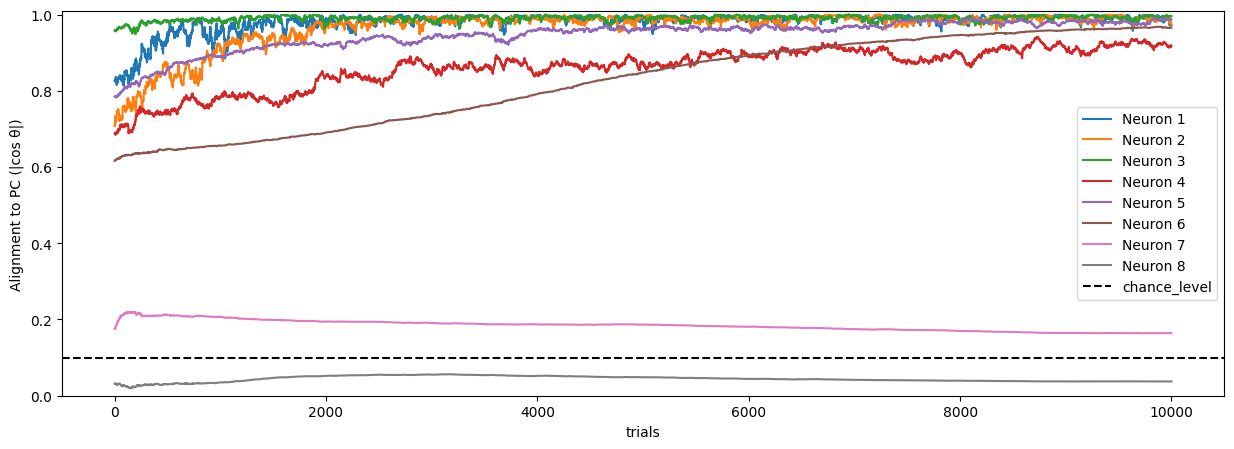

run  4
X_before
step    0 | order = [2 4 5 1 6 7 3 0] | best|corr|= [0.081 0.22  0.255 0.384 0.174 0.323 0.138 0.195]
step 1000 | order = [7 3 5 2 6 0 1 4] | best|corr|= [0.152 0.353 0.295 0.432 0.152 0.94  0.3   0.169]
step 2000 | order = [7 3 5 2 6 0 1 4] | best|corr|= [0.173 0.651 0.34  0.594 0.191 0.989 0.445 0.296]
step 3000 | order = [7 3 5 2 6 0 1 4] | best|corr|= [0.182 0.729 0.385 0.61  0.22  0.999 0.549 0.391]
step 4000 | order = [7 3 4 2 6 0 1 5] | best|corr|= [0.186 0.801 0.557 0.589 0.239 0.989 0.545 0.37 ]
step 5000 | order = [7 3 4 2 6 0 1 5] | best|corr|= [0.188 0.737 0.566 0.696 0.265 0.987 0.491 0.478]
step 6000 | order = [7 3 4 2 6 0 1 5] | best|corr|= [0.184 0.741 0.502 0.666 0.288 0.992 0.587 0.573]
step 7000 | order = [7 3 4 2 6 0 1 5] | best|corr|= [0.19  0.772 0.419 0.732 0.314 0.997 0.579 0.658]
step 8000 | order = [7 3 4 2 6 0 1 5] | best|corr|= [0.205 0.878 0.402 0.819 0.334 0.977 0.497 0.744]
step 9000 | order = [7 3 4 2 6 0 1 5] | best|corr|= [0.218 0.935 0

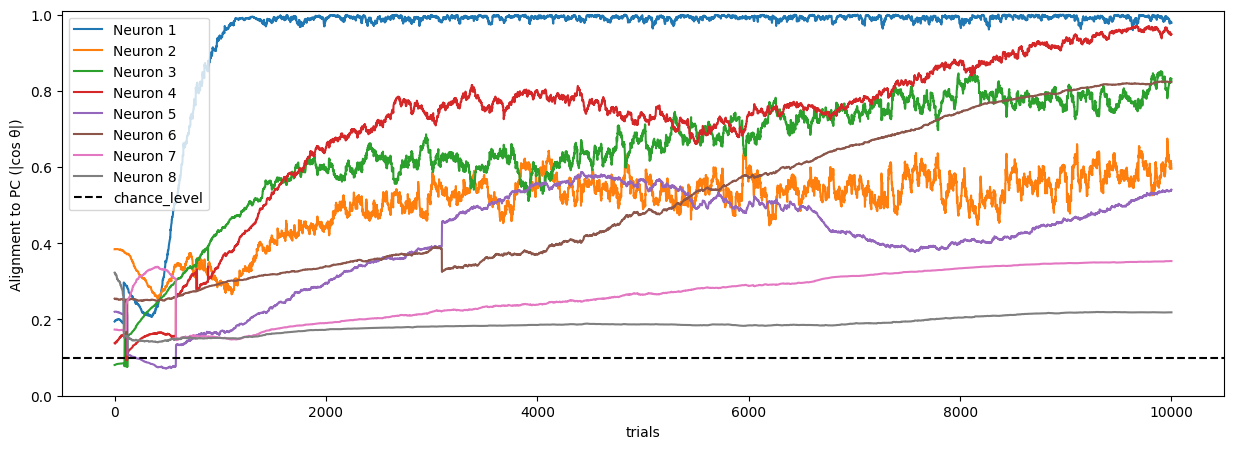

X_after
step    0 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.091 0.825 0.549 0.744 0.298 0.836 0.437 0.778]
step 1000 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.103 0.927 0.668 0.665 0.338 0.969 0.668 0.784]
step 2000 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.103 0.959 0.718 0.79  0.336 0.981 0.587 0.794]
step 3000 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.106 0.983 0.765 0.821 0.34  0.998 0.654 0.805]
step 4000 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.107 0.966 0.81  0.796 0.342 0.993 0.77  0.825]
step 5000 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.107 0.974 0.83  0.903 0.346 0.984 0.679 0.856]
step 6000 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.102 0.981 0.84  0.852 0.349 0.985 0.807 0.888]
step 7000 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.096 0.99  0.865 0.903 0.353 0.997 0.762 0.912]
step 8000 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.09  0.99  0.885 0.936 0.359 0.983 0.697 0.935]
step 9000 | order = [6 3 4 2 7 0 1 5] | best|corr|= [0.082 0.979 0.89  0.9

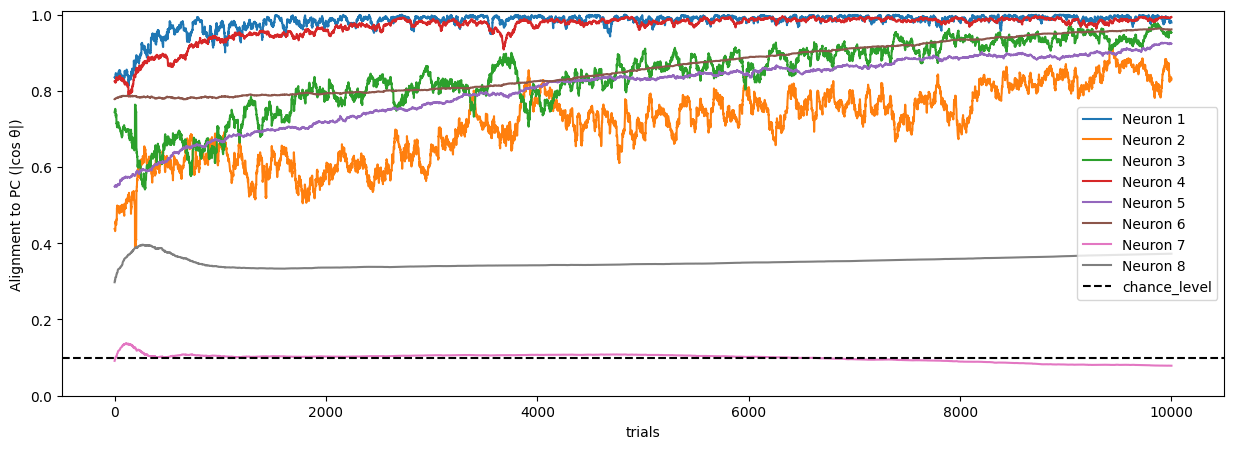

run  5
X_before
step    0 | order = [5 0 1 6 3 4 7 2] | best|corr|= [0.27  0.07  0.194 0.104 0.279 0.184 0.052 0.207]
step 1000 | order = [5 2 1 6 3 4 7 0] | best|corr|= [0.294 0.193 0.529 0.076 0.395 0.305 0.074 0.96 ]
step 2000 | order = [5 2 1 6 3 4 7 0] | best|corr|= [0.345 0.282 0.972 0.092 0.607 0.508 0.059 0.994]
step 3000 | order = [5 2 1 6 3 4 7 0] | best|corr|= [0.395 0.359 0.993 0.111 0.837 0.718 0.063 0.995]
step 4000 | order = [5 2 1 6 3 4 7 0] | best|corr|= [0.448 0.491 0.993 0.129 0.929 0.885 0.07  0.991]
step 5000 | order = [5 2 1 6 3 4 7 0] | best|corr|= [0.499 0.658 0.996 0.143 0.968 0.944 0.072 0.979]
step 6000 | order = [5 2 1 6 3 4 7 0] | best|corr|= [0.541 0.742 0.995 0.155 0.979 0.957 0.073 0.98 ]
step 7000 | order = [5 2 1 6 3 4 7 0] | best|corr|= [0.577 0.864 0.992 0.163 0.984 0.98  0.077 0.996]
step 8000 | order = [5 2 1 6 3 4 7 0] | best|corr|= [0.614 0.926 0.99  0.173 0.977 0.99  0.08  0.979]
step 9000 | order = [5 2 1 6 3 4 7 0] | best|corr|= [0.647 0.951 0

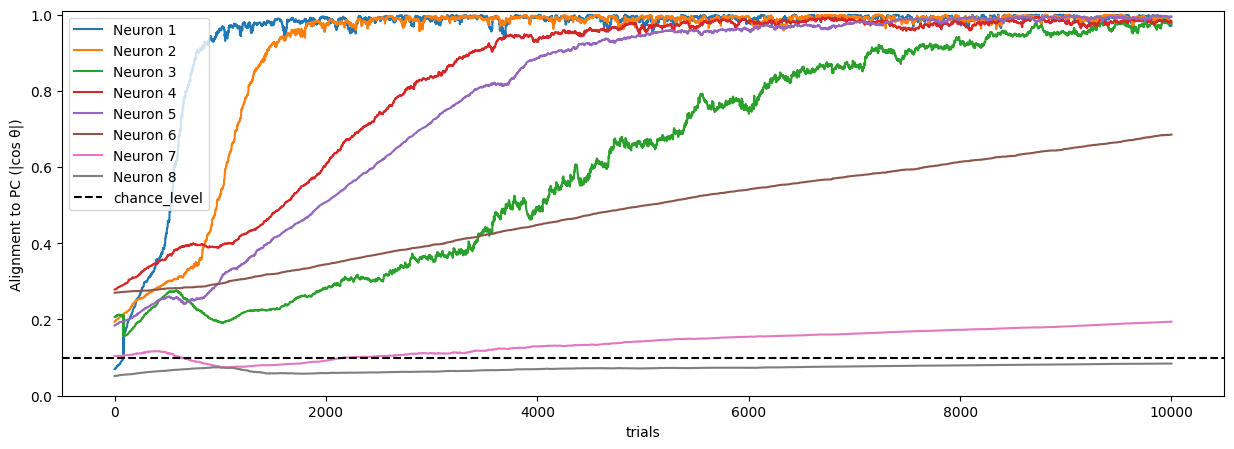

X_after
step    0 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.642 0.932 0.717 0.177 0.908 0.919 0.028 0.829]
step 1000 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.69  0.962 0.929 0.185 0.985 0.97  0.046 0.958]
step 2000 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.729 0.972 0.979 0.186 0.99  0.988 0.046 0.991]
step 3000 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.768 0.969 0.996 0.186 0.989 0.995 0.045 0.996]
step 4000 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.808 0.994 0.991 0.182 0.982 0.995 0.047 0.992]
step 5000 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.847 0.992 0.994 0.177 0.978 0.996 0.049 0.981]
step 6000 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.88  0.996 0.989 0.171 0.992 0.985 0.051 0.984]
step 7000 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.905 0.997 0.988 0.166 0.995 0.999 0.054 0.996]
step 8000 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.928 0.978 0.986 0.161 0.994 0.999 0.057 0.983]
step 9000 | order = [5 2 1 7 3 4 6 0] | best|corr|= [0.943 0.997 0.998 0.1

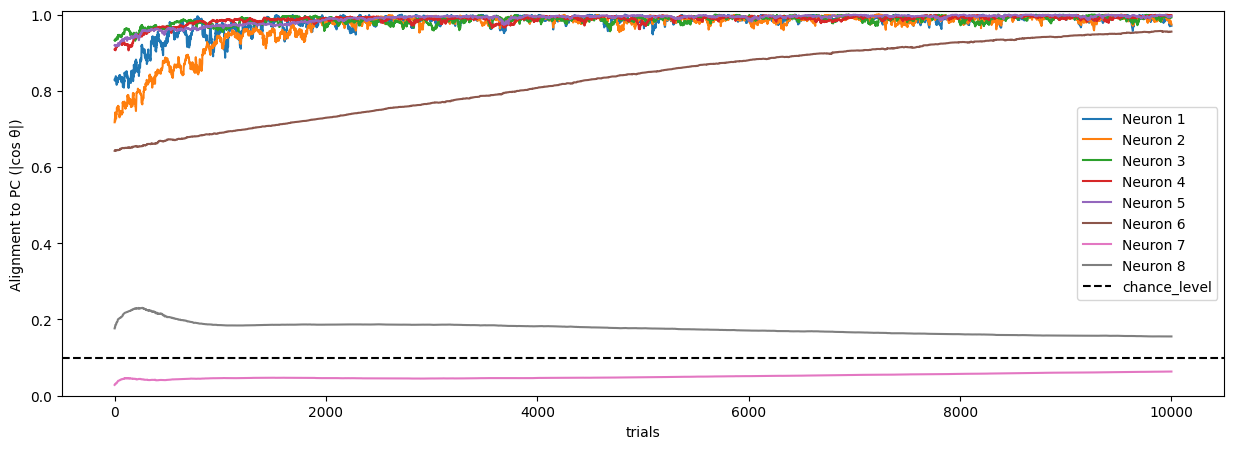

run  6
X_before
step    0 | order = [4 5 0 6 3 1 7 2] | best|corr|= [0.291 0.077 0.235 0.295 0.358 0.222 0.263 0.118]
step 1000 | order = [4 5 2 0 3 1 6 7] | best|corr|= [0.302 0.066 0.269 0.909 0.563 0.836 0.214 0.147]
step 2000 | order = [4 6 2 0 3 1 7 5] | best|corr|= [0.397 0.213 0.333 0.99  0.761 0.99  0.281 0.026]
step 3000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.487 0.113 0.554 0.993 0.832 0.997 0.291 0.174]
step 4000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.688 0.137 0.528 0.989 0.897 0.994 0.297 0.193]
step 5000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.846 0.166 0.632 0.983 0.868 0.991 0.302 0.187]
step 6000 | order = [4 5 2 0 3 1 6 7] | best|corr|= [0.927 0.2   0.613 0.987 0.91  0.995 0.273 0.219]
step 7000 | order = [4 5 2 0 3 1 6 7] | best|corr|= [0.968 0.237 0.672 0.996 0.903 0.995 0.291 0.226]
step 8000 | order = [4 5 2 0 3 1 6 7] | best|corr|= [0.983 0.282 0.637 0.986 0.917 0.991 0.306 0.226]
step 9000 | order = [4 5 2 0 3 1 6 7] | best|corr|= [0.987 0.333 0

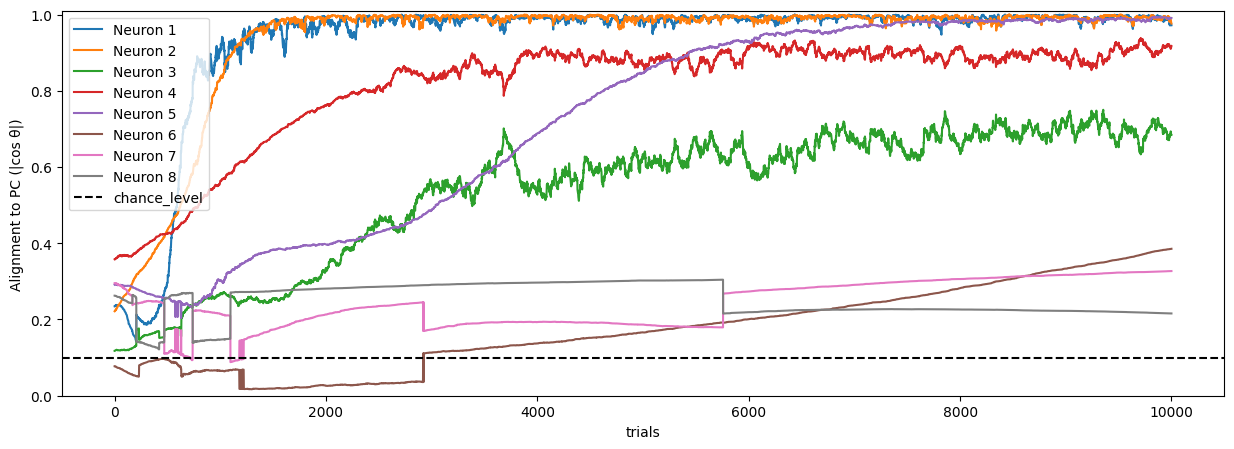

X_after
step    0 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.907 0.418 0.663 0.835 0.894 0.722 0.329 0.012]
step 1000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.948 0.472 0.734 0.952 0.931 0.922 0.353 0.056]
step 2000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.966 0.508 0.753 0.993 0.938 0.981 0.339 0.053]
step 3000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.982 0.539 0.852 0.996 0.901 0.996 0.337 0.05 ]
step 4000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.988 0.564 0.74  0.989 0.97  0.991 0.338 0.051]
step 5000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.993 0.591 0.826 0.982 0.949 0.994 0.338 0.054]
step 6000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.983 0.618 0.799 0.984 0.983 0.991 0.34  0.058]
step 7000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.998 0.646 0.876 0.996 0.976 0.989 0.345 0.061]
step 8000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.998 0.682 0.891 0.982 0.969 0.989 0.351 0.065]
step 9000 | order = [4 5 2 0 3 1 7 6] | best|corr|= [0.998 0.718 0.899 0.9

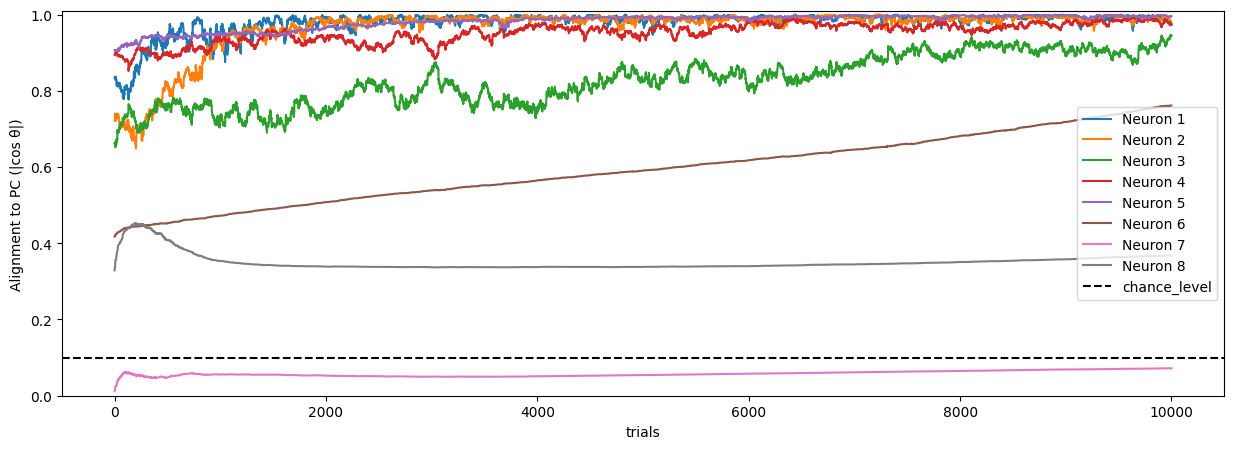

run  7
X_before
step    0 | order = [5 4 6 2 1 0 7 3] | best|corr|= [0.26  0.174 0.107 0.206 0.273 0.174 0.21  0.226]
step 1000 | order = [5 1 4 0 3 6 7 2] | best|corr|= [0.372 0.243 0.317 0.719 0.381 0.057 0.238 0.517]
step 2000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.415 0.418 0.438 0.945 0.415 0.051 0.247 0.794]
step 3000 | order = [5 3 4 0 1 7 6 2] | best|corr|= [0.465 0.488 0.544 0.992 0.585 0.153 0.15  0.902]
step 4000 | order = [5 3 4 0 1 7 6 2] | best|corr|= [0.516 0.606 0.657 0.994 0.609 0.152 0.161 0.862]
step 5000 | order = [5 3 4 0 1 7 6 2] | best|corr|= [0.546 0.695 0.727 0.989 0.688 0.145 0.172 0.909]
step 6000 | order = [5 3 4 0 1 7 6 2] | best|corr|= [0.552 0.78  0.798 0.977 0.785 0.138 0.17  0.879]
step 7000 | order = [5 3 4 0 1 7 6 2] | best|corr|= [0.557 0.796 0.892 0.997 0.889 0.135 0.173 0.931]
step 8000 | order = [5 3 4 0 1 7 6 2] | best|corr|= [0.557 0.82  0.938 0.982 0.954 0.133 0.179 0.931]
step 9000 | order = [5 3 4 0 1 7 6 2] | best|corr|= [0.56  0.843 0

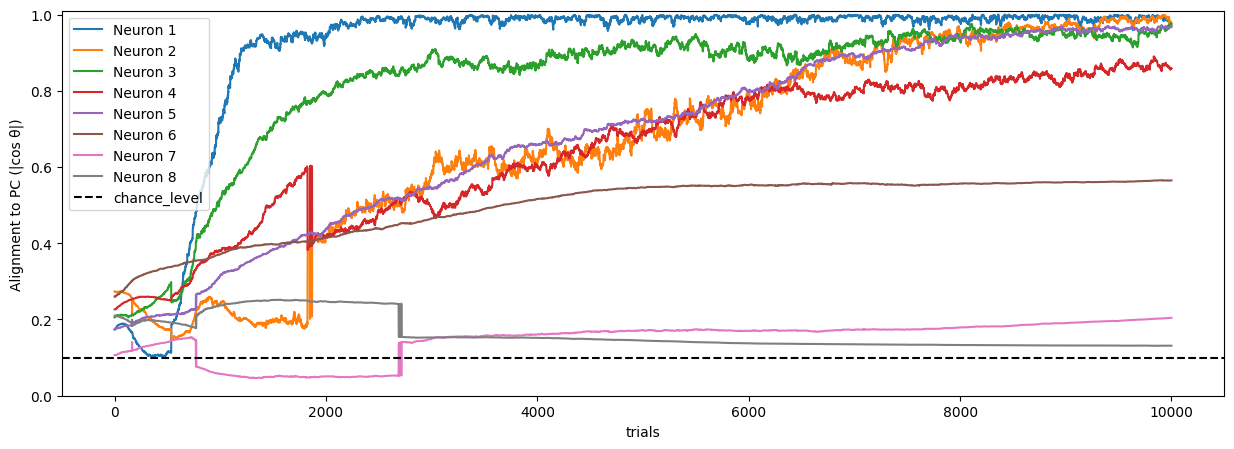

X_after
step    0 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.571 0.715 0.915 0.828 0.696 0.067 0.255 0.94 ]
step 1000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.619 0.798 0.969 0.954 0.907 0.093 0.265 0.955]
step 2000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.652 0.861 0.976 0.99  0.973 0.094 0.262 0.952]
step 3000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.692 0.899 0.974 0.996 0.993 0.095 0.27  0.944]
step 4000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.74  0.875 0.984 0.993 0.991 0.098 0.284 0.978]
step 5000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.793 0.905 0.979 0.98  0.995 0.1   0.3   0.982]
step 6000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.84  0.916 0.972 0.986 0.99  0.104 0.316 0.99 ]
step 7000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.876 0.93  0.985 0.996 0.99  0.108 0.333 0.988]
step 8000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.908 0.931 0.992 0.983 0.987 0.112 0.35  0.963]
step 9000 | order = [5 3 4 0 1 6 7 2] | best|corr|= [0.93  0.933 0.991 0.9

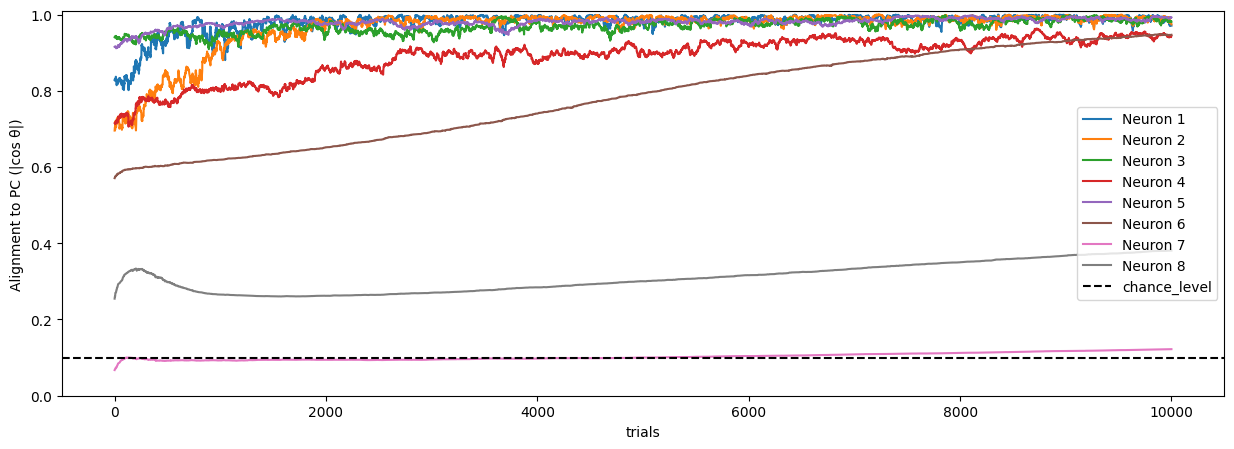

run  8
X_before
step    0 | order = [3 5 6 1 0 7 4 2] | best|corr|= [0.177 0.36  0.092 0.17  0.149 0.09  0.189 0.156]
step 1000 | order = [2 5 3 1 0 7 6 4] | best|corr|= [0.163 0.416 0.335 0.328 0.902 0.099 0.092 0.148]
step 2000 | order = [6 5 3 1 0 7 4 2] | best|corr|= [0.04  0.482 0.524 0.763 0.985 0.116 0.396 0.176]
step 3000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.051 0.485 0.618 0.977 0.998 0.128 0.484 0.313]
step 4000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.04  0.521 0.468 0.985 0.985 0.13  0.589 0.731]
step 5000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.019 0.557 0.567 0.974 0.981 0.123 0.751 0.808]
step 6000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.01  0.589 0.511 0.983 0.989 0.113 0.873 0.864]
step 7000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.004 0.604 0.579 0.986 0.996 0.1   0.945 0.839]
step 8000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.003 0.611 0.589 0.983 0.985 0.089 0.973 0.839]
step 9000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.001 0.617 0

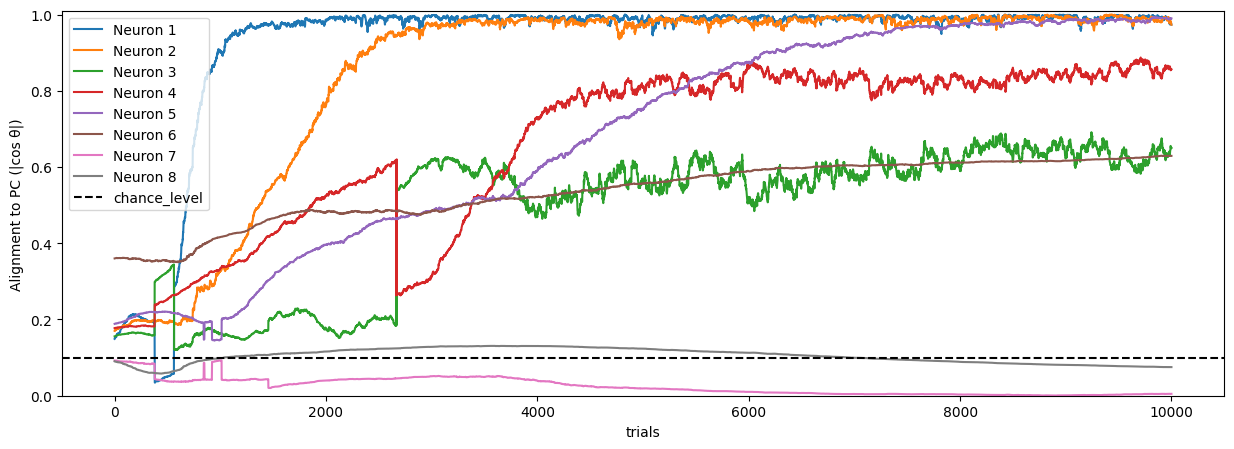

X_after
step    0 | order = [7 5 2 1 0 6 4 3] | best|corr|= [0.034 0.614 0.62  0.724 0.836 0.051 0.909 0.765]
step 1000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.048 0.647 0.601 0.932 0.959 0.047 0.961 0.861]
step 2000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.062 0.683 0.627 0.978 0.993 0.043 0.982 0.863]
step 3000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.075 0.726 0.653 0.995 0.996 0.047 0.993 0.844]
step 4000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.088 0.775 0.57  0.992 0.991 0.057 0.994 0.911]
step 5000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.104 0.826 0.632 0.994 0.982 0.069 0.996 0.879]
step 6000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.116 0.868 0.616 0.994 0.982 0.081 0.985 0.922]
step 7000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.128 0.899 0.675 0.993 0.996 0.094 0.999 0.911]
step 8000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.139 0.926 0.645 0.99  0.987 0.106 0.999 0.923]
step 9000 | order = [6 5 2 1 0 7 4 3] | best|corr|= [0.149 0.943 0.7   0.9

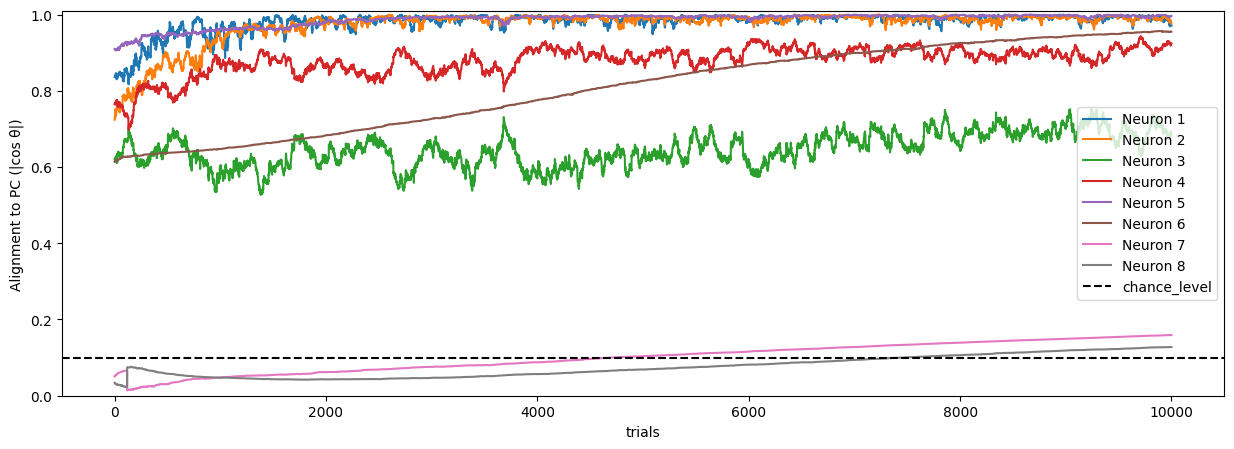

run  9
X_before
step    0 | order = [1 4 2 6 0 7 3 5] | best|corr|= [0.174 0.243 0.084 0.28  0.17  0.1   0.354 0.292]
step 1000 | order = [0 4 5 1 7 2 3 6] | best|corr|= [0.731 0.459 0.257 0.26  0.131 0.074 0.464 0.123]
step 2000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.934 0.429 0.312 0.506 0.129 0.023 0.729 0.255]
step 3000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.973 0.616 0.331 0.658 0.122 0.022 0.868 0.26 ]
step 4000 | order = [0 1 5 2 6 7 3 4] | best|corr|= [0.988 0.744 0.325 0.584 0.057 0.101 0.92  0.351]
step 5000 | order = [0 1 6 2 5 7 3 4] | best|corr|= [0.991 0.706 0.133 0.71  0.308 0.112 0.923 0.453]
step 6000 | order = [0 1 6 2 5 7 3 4] | best|corr|= [0.994 0.855 0.147 0.702 0.372 0.13  0.942 0.576]
step 7000 | order = [0 1 6 2 5 7 3 4] | best|corr|= [0.996 0.83  0.156 0.816 0.366 0.14  0.944 0.725]
step 8000 | order = [0 1 6 2 5 7 3 4] | best|corr|= [0.975 0.814 0.164 0.834 0.319 0.147 0.959 0.84 ]
step 9000 | order = [0 1 6 2 5 7 3 4] | best|corr|= [0.999 0.873 0

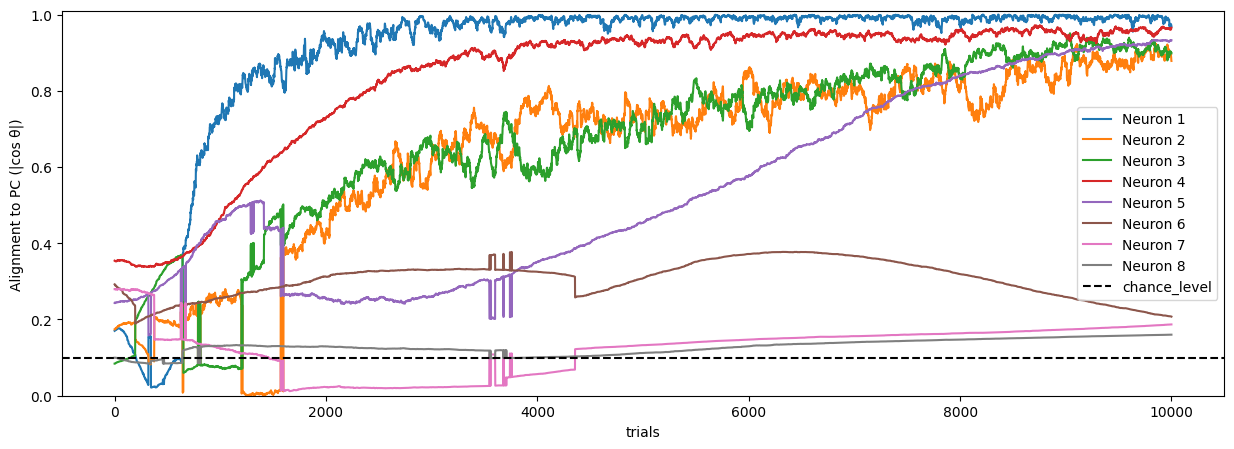

X_after
step    0 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.826 0.587 0.234 0.847 0.239 0.09  0.918 0.881]
step 1000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.963 0.797 0.241 0.915 0.242 0.138 0.971 0.933]
step 2000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.987 0.847 0.234 0.933 0.243 0.131 0.986 0.96 ]
step 3000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.997 0.922 0.238 0.967 0.249 0.126 0.964 0.98 ]
step 4000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.991 0.937 0.25  0.947 0.259 0.126 0.981 0.986]
step 5000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.981 0.933 0.267 0.97  0.27  0.129 0.971 0.99 ]
step 6000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.984 0.943 0.292 0.963 0.28  0.133 0.989 0.98 ]
step 7000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.996 0.938 0.322 0.99  0.291 0.138 0.992 0.994]
step 8000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.984 0.935 0.363 0.981 0.302 0.144 0.987 0.995]
step 9000 | order = [0 1 5 2 7 6 3 4] | best|corr|= [0.998 0.982 0.411 0.9

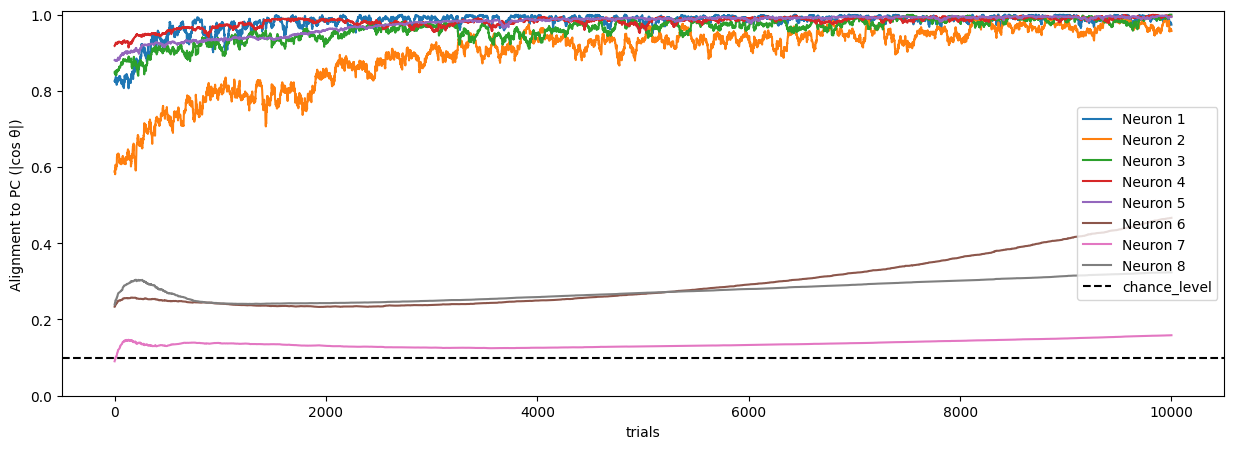

run 10
X_before
step    0 | order = [0 1 3 5 7 4 6 2] | best|corr|= [0.289 0.126 0.189 0.209 0.224 0.235 0.219 0.241]
step 1000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.952 0.237 0.228 0.206 0.291 0.256 0.163 0.508]
step 2000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.982 0.683 0.228 0.251 0.495 0.375 0.229 0.68 ]
step 3000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.993 0.861 0.248 0.324 0.69  0.538 0.273 0.765]
step 4000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.994 0.815 0.248 0.353 0.821 0.616 0.298 0.865]
step 5000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.986 0.927 0.235 0.367 0.896 0.622 0.312 0.814]
step 6000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.979 0.867 0.227 0.38  0.903 0.676 0.324 0.938]
step 7000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.996 0.928 0.225 0.391 0.93  0.687 0.339 0.927]
step 8000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.974 0.956 0.226 0.406 0.942 0.708 0.352 0.911]
step 9000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.999 0.965 0

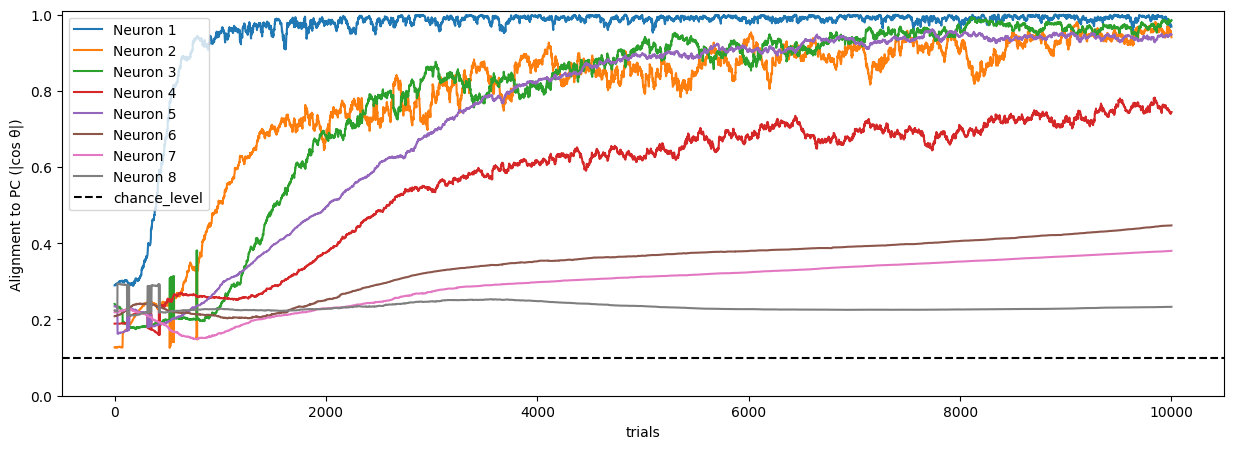

X_after
step    0 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.824 0.934 0.204 0.427 0.894 0.596 0.196 0.657]
step 1000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.955 0.942 0.214 0.456 0.939 0.657 0.208 0.878]
step 2000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.989 0.955 0.216 0.496 0.934 0.735 0.202 0.939]
step 3000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.997 0.953 0.221 0.543 0.937 0.766 0.212 0.974]
step 4000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.993 0.981 0.227 0.597 0.953 0.744 0.221 0.974]
step 5000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.979 0.988 0.234 0.66  0.954 0.774 0.23  0.973]
step 6000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.985 0.993 0.24  0.721 0.945 0.795 0.239 0.97 ]
step 7000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.996 0.994 0.247 0.774 0.962 0.815 0.249 0.97 ]
step 8000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.983 0.973 0.253 0.823 0.973 0.818 0.258 0.967]
step 9000 | order = [0 2 7 5 4 3 6 1] | best|corr|= [0.999 0.993 0.26  0.8

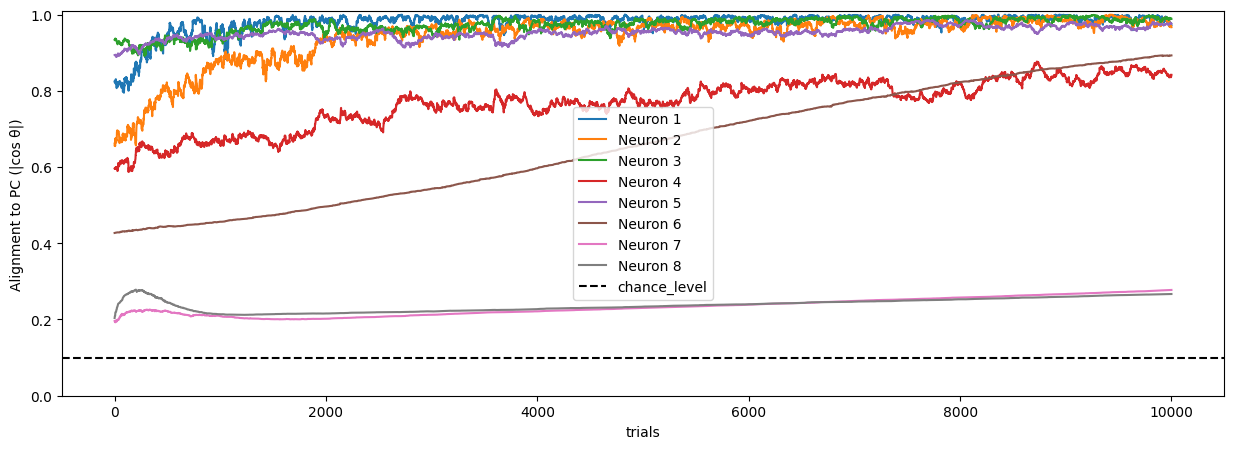

<Figure size 640x480 with 0 Axes>

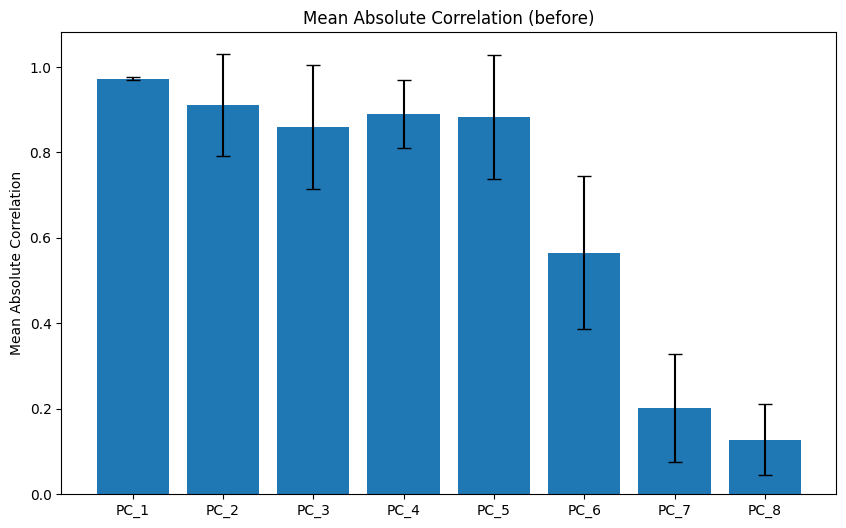

<Figure size 640x480 with 0 Axes>

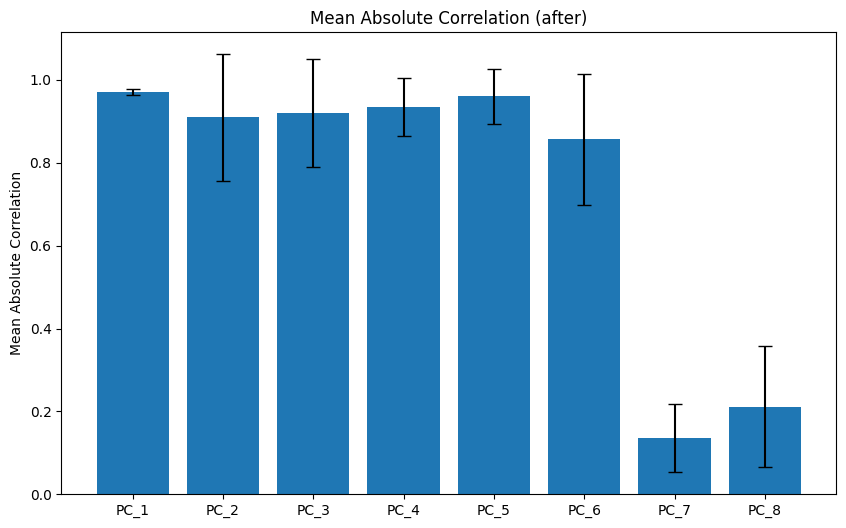

In [5]:
from hebbian.utils import two_phase_training_testing

two_phase_training_testing(models["OneShotLeenCompletePCA"], X_before, X_after, m, 
                            # model_paras_after = model_paras_after, 
                            runs = 10, graph = True)

### Decoding task variable by different models

In [6]:
def run_experiment(model, data, params, pcs, scores, runs, batch_size, output_size):
    task_var, df_task_var_tilde = decoding_task_variable_optimized(model, data, params, 
                                                            pcs, scores, 
                                                            batch_size, output_size, 
                                                            runs, graph=False)
    mean_df_task_var_tilde = df_task_var_tilde.mean(axis=0)
    std_df_task_var_tilde = df_task_var_tilde.std(axis=0)

    df_task_var_random = get_task_variable_random(model, data, params, pcs, scores)
    mean_df_task_var_random = df_task_var_random.mean(axis=0)
    std_df_task_var_random = df_task_var_random.std(axis=0)

    plot_task_variable_decoding(task_var, 
                                mean_df_task_var_random, mean_df_task_var_tilde, 
                                std_df_task_var_random, std_df_task_var_tilde, 
                                model, display_length=200)

Runs: 100%|██████████| 100/100 [00:00<00:00, 873.87it/s]


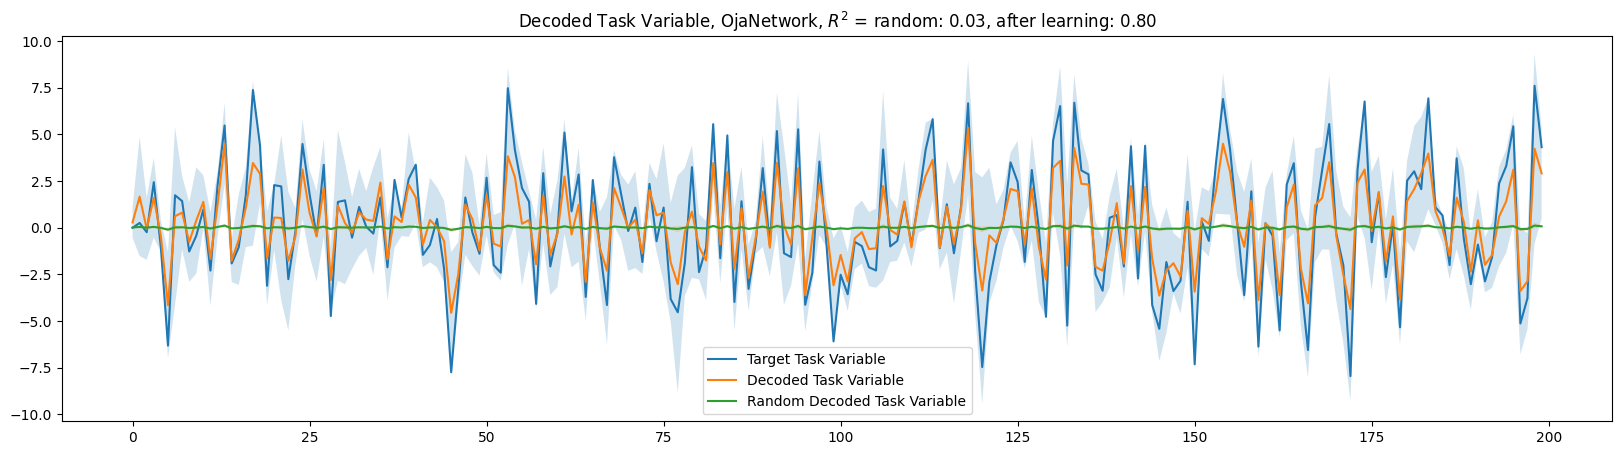

Runs: 100%|██████████| 100/100 [00:00<00:00, 929.79it/s]


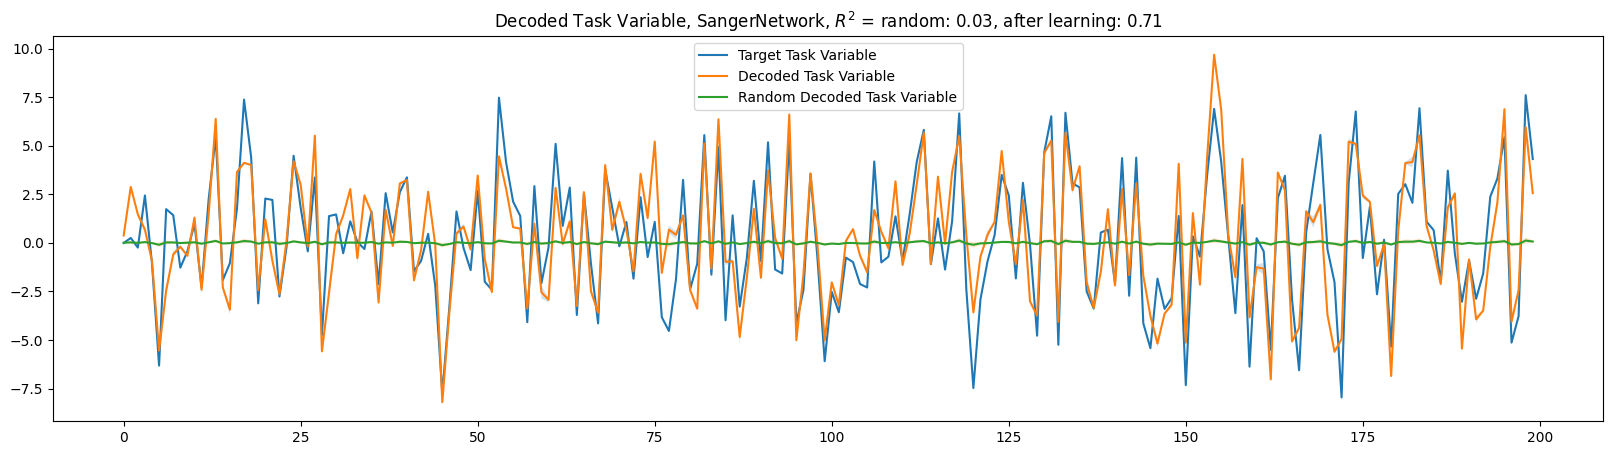

Runs: 100%|██████████| 100/100 [00:00<00:00, 744.20it/s]


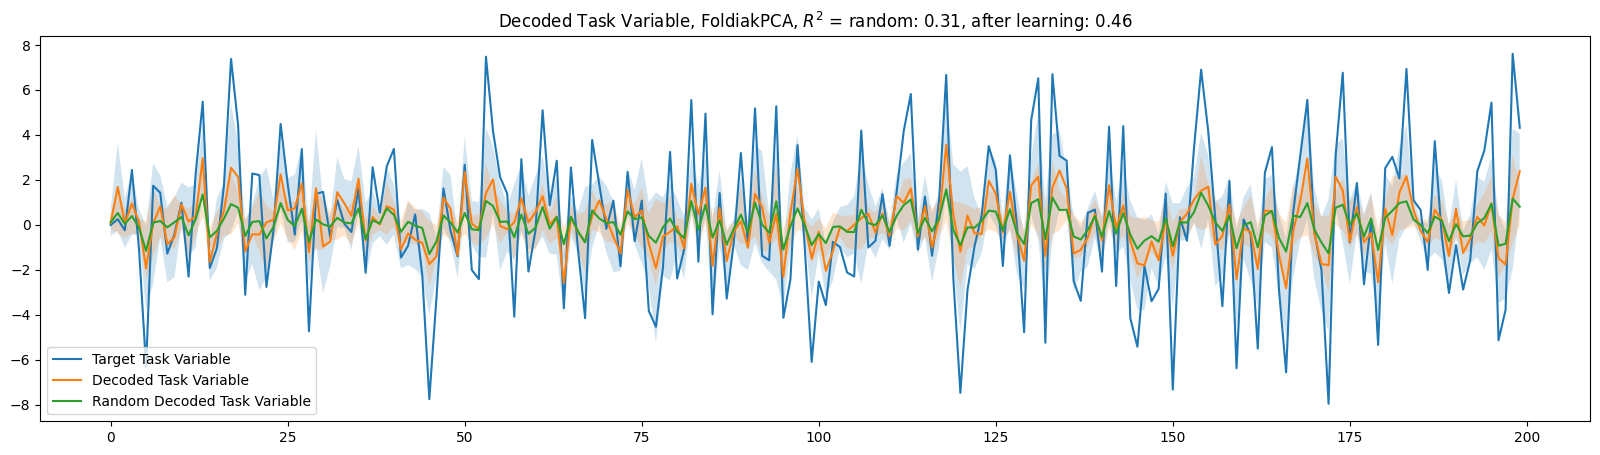

Runs: 100%|██████████| 100/100 [00:00<00:00, 694.43it/s]


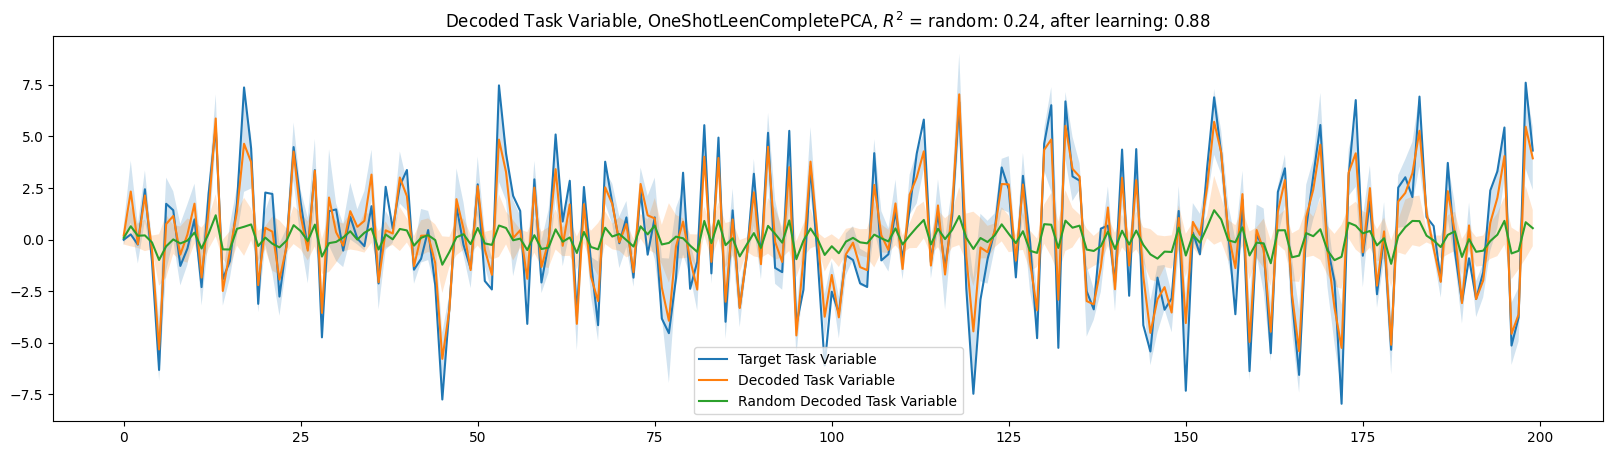

Runs: 100%|██████████| 100/100 [00:00<00:00, 691.15it/s]


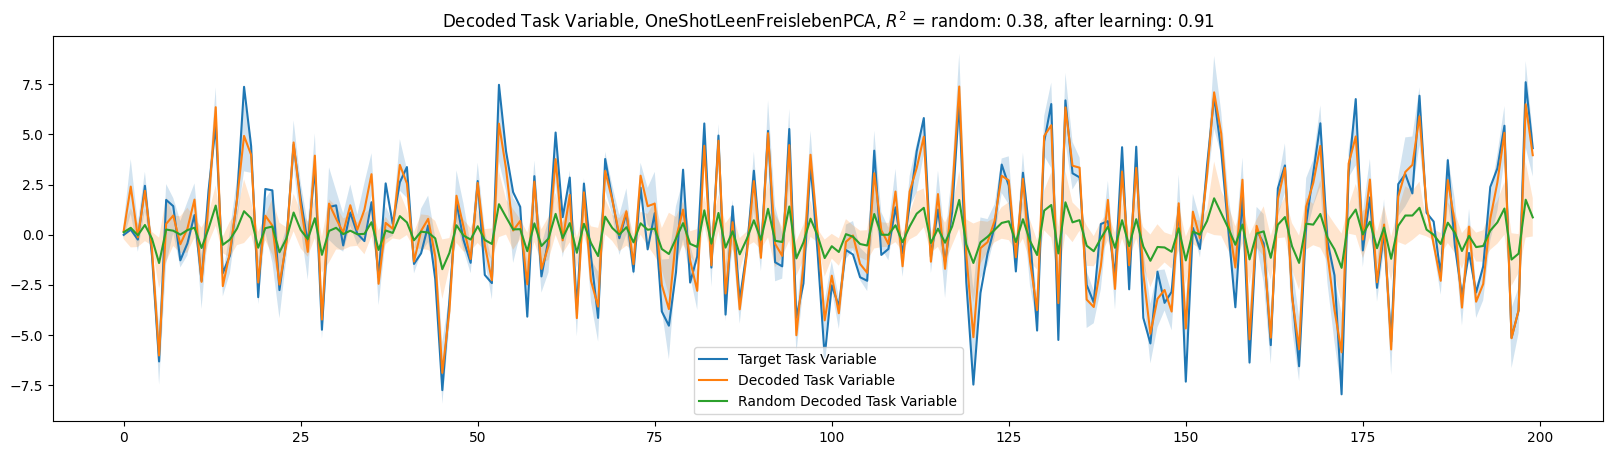

In [7]:
for model in models.keys():
    run_experiment(models[model], data = X_before, 
                    params=params, pcs=pcs_before, scores=scores_before, 
                    batch_size=1, output_size=m, runs=runs)
